<a href="https://colab.research.google.com/github/dimasjanotama/data-science-2026/blob/main/Pertemuan4_%5BDimas_Janotama%5D_%5B240401010264%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Dimas Prih P J<br>
NIM : 240401010264<br>
Kelas : IF403<br>

In [ ]:
#1. Load & Inspect Database
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print('--- Dari hasil tersebut dapat diketahui bahwa data tersebut memiliki 150 kolom dan 5 baris. ---\n')
print(df.dtypes)
print('--- Dari hasil tersebut dapat diketahui bahwa data tersebut terdiri dari data sepal_length, sepal_width, petal_length, petal_width, species dengan masing masing tipe data tertera pada hasil. ---\n')
print(df.head())
print('--- Hasil diatas merupakan 5 data pertama dari data iris ---\n')
print(df.describe().round(3))
print('--- Hasil diatas merupakan tabel ringkasan yang mencakup count, mean, std, min, Q1, median, Q3, dan max untuk setiap kolom numerik ---\n')

In [ ]:
#2. Statistik Deskriptif Lengkap
print('--- Berikut merupakan Statistik Deskriptif untuk Tiap Kolom dalam Data Iris ---')
for col_name in df.select_dtypes(include='number').columns:
    col = df[col_name]
    print(f'\n=== {col_name} ===')
    print(f'  Mean     : {col.mean():.3f}')
    print(f'  Median   : {col.median():.3f}')
    print(f'  Std Dev  : {col.std():.3f}')
    print(f'  Skewness : {col.skew():.3f}')
    print(f'  Kurtosis : {col.kurt():.3f}')

In [ ]:
#3. Analisis Distribusi (Histogram + KDE)
print('---- Berikut merupakan Histogram + KDE untuk sepal_length beserta garis mean dan mediannya ---\n')
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['sepal_length'], kde=True,
             color='#028090', bins=20, ax=ax)
ax.axvline(df['sepal_length'].mean(), color='red',
           linestyle='--', label=f"Mean={df['sepal_length'].mean():.2f}")
ax.axvline(df['sepal_length'].median(), color='orange',
           linestyle='--', label=f"Median={df['sepal_length'].median():.2f}")
ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()

print('\nDari hasil tersebut dapat diketahui kesimpulan berikut : ')
print('Data sepal_length mendekati distribusi normal karena mean hanya selisih sekitar 0,04 dengan median,\nData sepal_length bentuk histogram cukup simetris,\nData sepal_length untuk skewness sedikit miring ke kanan (positif).\n')

In [ ]:
#4. Boxplot per Spesies
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='species', y='petal_length',
            hue='species', palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(data=df, x='species', y='petal_length',
               hue='species', palette='Set2', inner='box', legend=False, ax=axes[1])

print('\nDari hasil boxplot dan violinplot berikut dapat diketahui kesimpulan bahwa Spesies viginica memiliki petal_lenght paling besar,\nsedangkan sentosa merupakan spesies dengan petal_length paling kecil.\n')

In [ ]:
#5. Matriks Korelasi Pearson

print('--- Berikut hasil matriks korelasi Pearson ---\n')
corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))
import numpy as np
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')
print(f"Korelasi terendah  : {min_pair} = {corr.loc[min_pair]:.3f}")

print('\nDari hasil korelasi pearson diatas dapat diketahui hubungan korelasi tertinggi ada pada petal_width dan petal_length,\nartinya semakin lebar petal maka semakin panjang petalnya,\nsedangkan korelasi terendah ada pada petal_length dengan sepal_width,\nyang artinya lebar petal tidak berpengaruh pada lebar sepal.\n')

--- Berikut hasil Scatter Plot & Heatmap ---



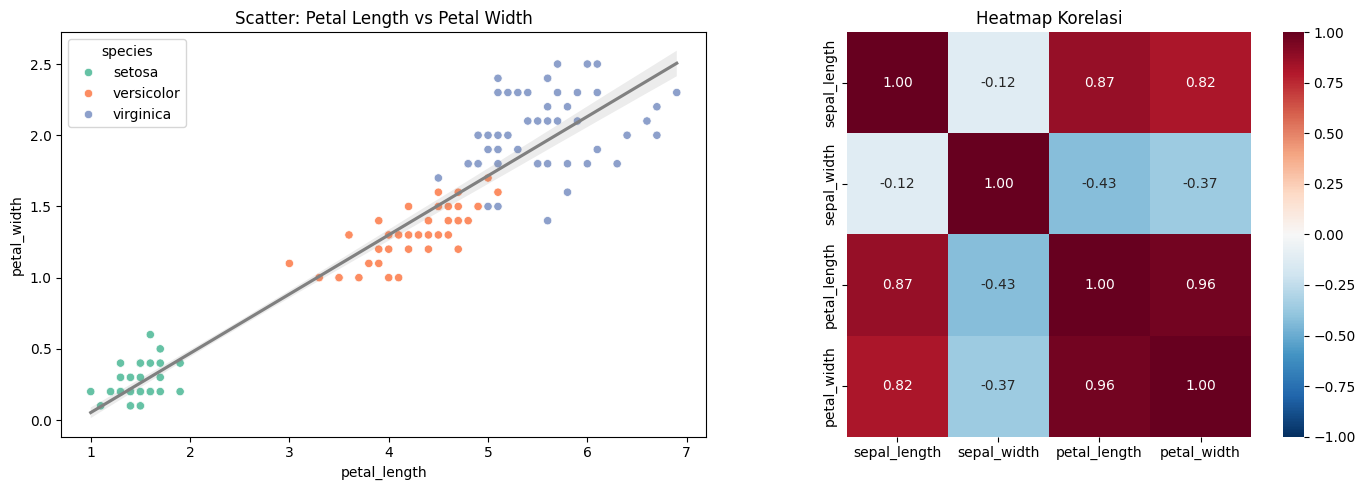


Dari scatter plot diatas dapat diketahui adanya hubungan positif antara petal_length dengan petal_width.
Sedangkan dari heatmap diatas dapat diketahui korelsi tertinggi ada pada petal_length dengan petal_width (warna merah kuat),
sedangkan korelasi terendah ada pada petal_length dengan sepal_width (warna biru kuat).



In [41]:
#6. Scatter Plot & Heatmap

print('--- Berikut hasil Scatter Plot & Heatmap ---\n')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='petal_length', y='petal_width',
                hue='species', palette='Set2', ax=axes[0])
sns.regplot(data=df, x='petal_length', y='petal_width',
            scatter=False, color='gray', ax=axes[0])
axes[0].set_title('Scatter: Petal Length vs Petal Width')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, square=True, ax=axes[1])
axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()

print('\nDari scatter plot diatas dapat diketahui adanya hubungan positif antara petal_length dengan petal_width.\nSedangkan dari heatmap diatas dapat diketahui korelsi tertinggi ada pada petal_length dengan petal_width (warna merah kuat),\nsedangkan korelasi terendah ada pada petal_length dengan sepal_width (warna biru kuat).\n')

#Yang Saya Pelajari
Pada pertemuan ini, saya mempelajari serangkaian analisis data eksploratif, mulai dari memuat serta memeriksa integritas dataset hingga memahami karakteristiknya melalui statistik deskriptif dan visualisasi distribusi. Saya juga telah mendalami kaitan antar variabel dengan menggunakan boxplot dan violin plot, serta mengidentifikasi pola hubungan antar variabel numerik melalui analisis korelasi Pearson yang divisualisasikan dengan heatmap dan scatter plot.